Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

Load Dataset

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/train.csv")

print(df.head())
print(df.info())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

Data Cleaning and preprocessing

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
print(df.isnull().sum())
df = df.drop_duplicates()
df = df.sort_values(by='Order Date')

print("Cleaned Data Shape:", df.shape)

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64
Cleaned Data Shape: (9800, 18)


Descriptive Statistics

In [10]:
print("Total Sales:", df['Sales'].sum())
print("Average Sales:", df['Sales'].mean())
print("Maximum Sales:", df['Sales'].max())
print("Minimum Sales:", df['Sales'].min())

print(df.describe())

Total Sales: 2261536.7827000003
Average Sales: 230.7690594591837
Maximum Sales: 22638.48
Minimum Sales: 0.444
            Row ID                     Order Date   Postal Code         Sales
count  9800.000000                           9800   9789.000000   9800.000000
mean   4900.500000  2017-05-01 05:13:51.673469440  55273.322403    230.769059
min       1.000000            2015-01-03 00:00:00   1040.000000      0.444000
25%    2450.750000            2016-05-24 00:00:00  23223.000000     17.248000
50%    4900.500000            2017-06-26 00:00:00  58103.000000     54.490000
75%    7350.250000            2018-05-15 00:00:00  90008.000000    210.605000
max    9800.000000            2018-12-30 00:00:00  99301.000000  22638.480000
std    2829.160653                            NaN  32041.223413    626.651875


Sales Trend Analysis (Time Series)

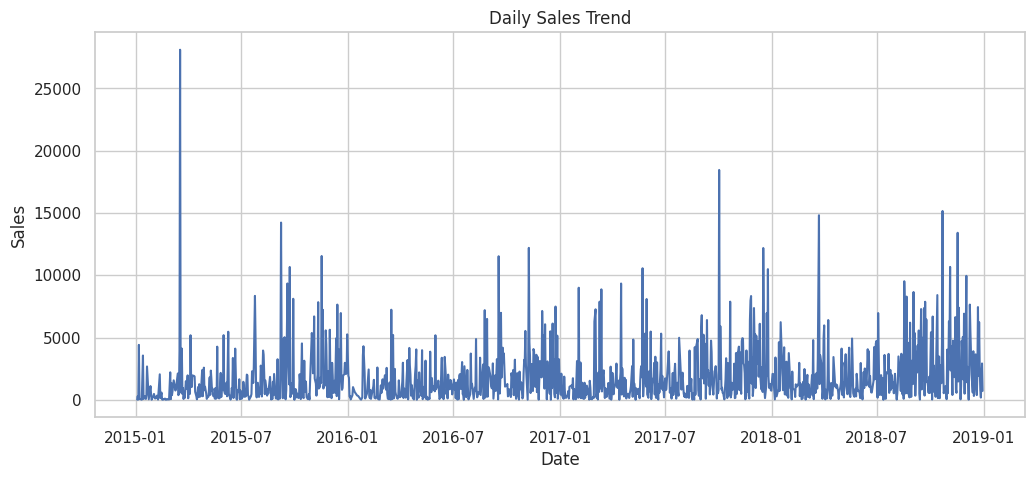

In [12]:
daily_sales = df.groupby('Order Date')['Sales'].sum()

plt.figure(figsize=(12,5))
plt.plot(daily_sales)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

Monthly & Yearly Analysis

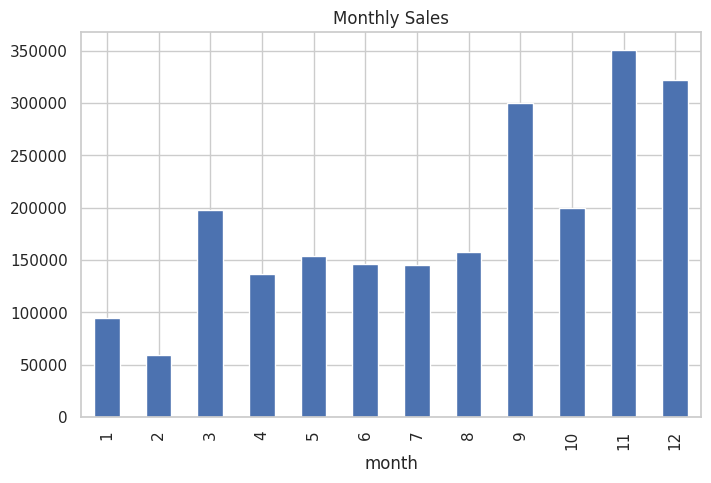

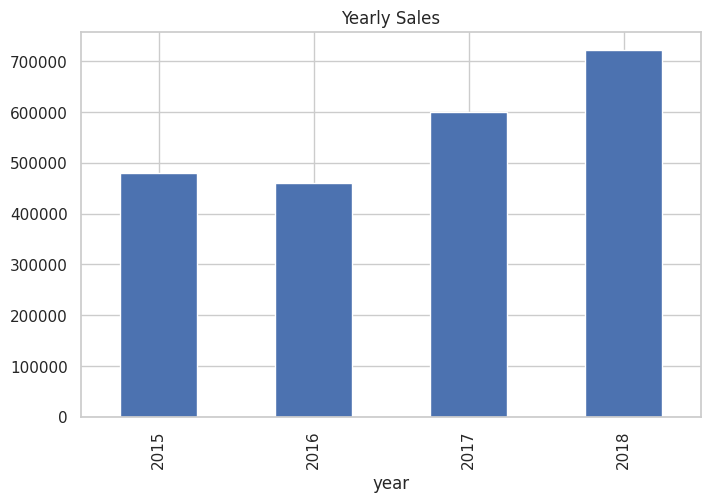

In [14]:
df['year'] = df['Order Date'].dt.year
df['month'] = df['Order Date'].dt.month

monthly_sales = df.groupby('month')['Sales'].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot(kind='bar')
plt.title("Monthly Sales")
plt.show()

yearly_sales = df.groupby('year')['Sales'].sum()

plt.figure(figsize=(8,5))
yearly_sales.plot(kind='bar')
plt.title("Yearly Sales")
plt.show()

Store Analysis

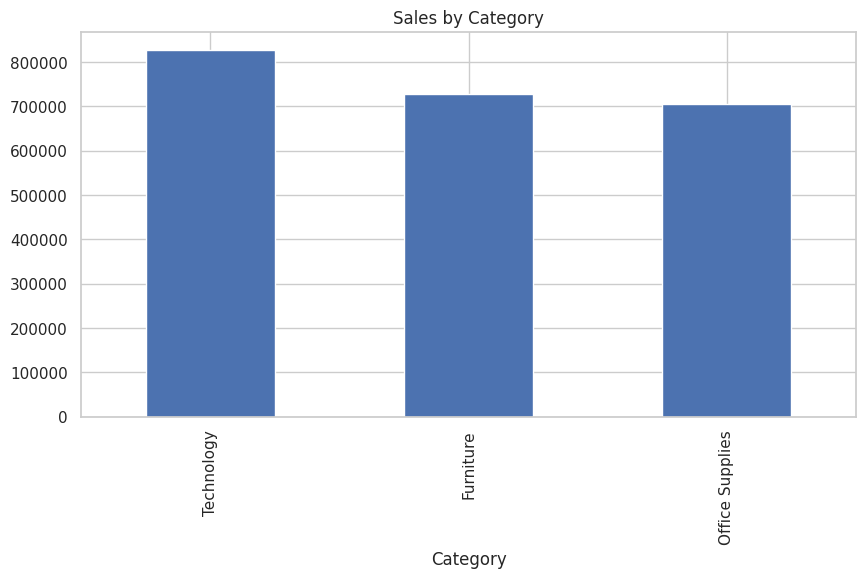

In [16]:
store_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
store_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

Product (Item) Analysis

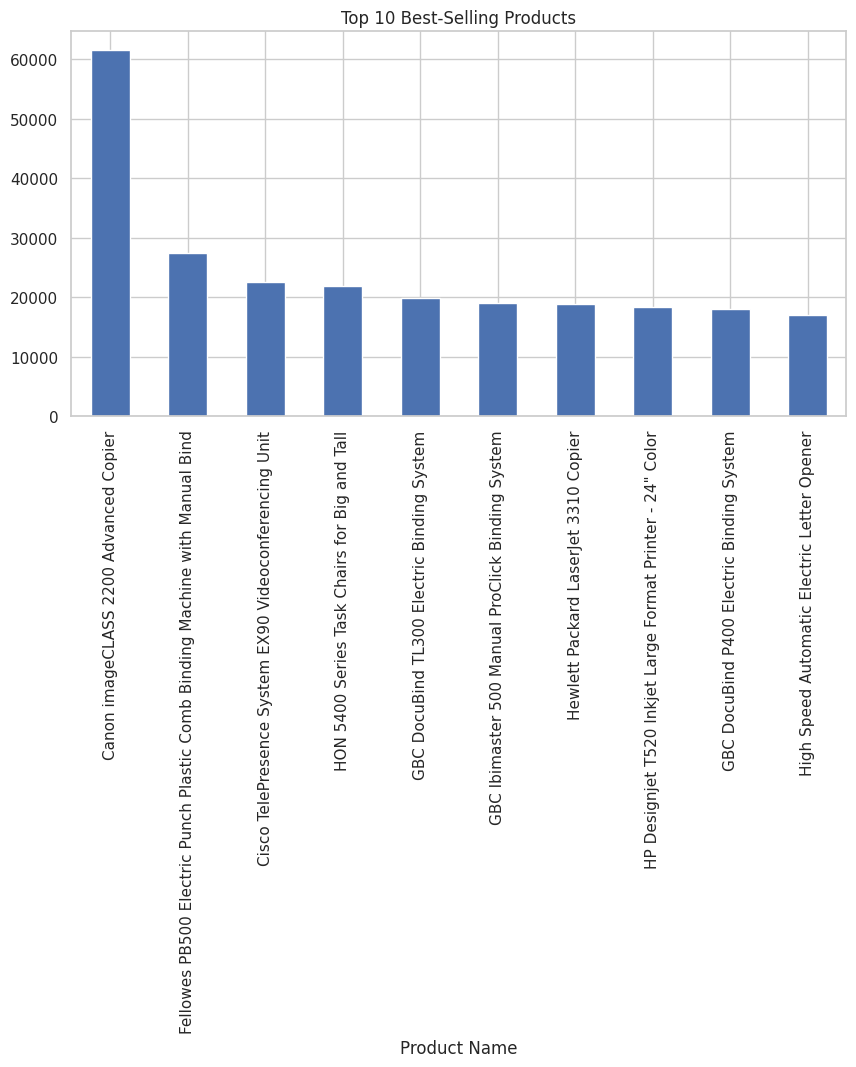

In [18]:
item_sales = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)

top_items = item_sales.head(10)

plt.figure(figsize=(10,5))
top_items.plot(kind='bar')
plt.title("Top 10 Best-Selling Products")
plt.show()

Sales Distribution

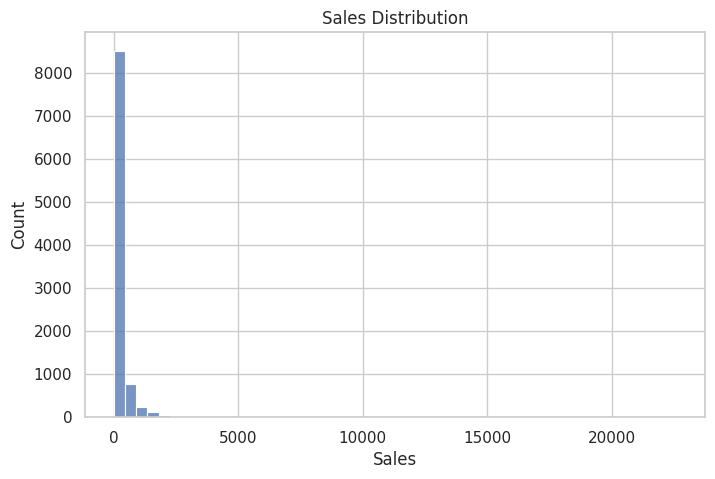

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=50)
plt.title("Sales Distribution")
plt.show()

Box Plot

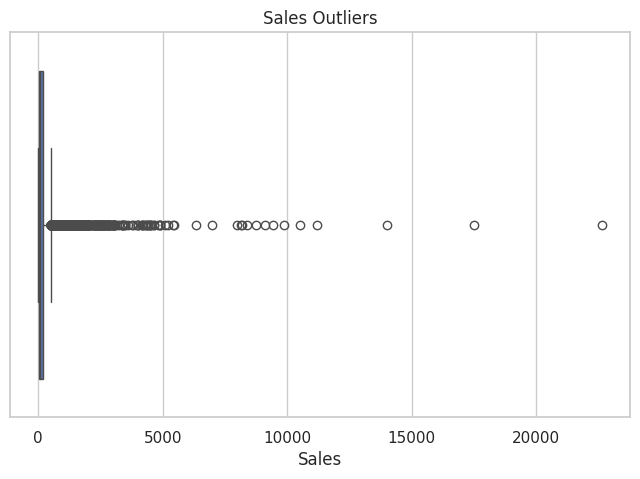

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Sales'])
plt.title("Sales Outliers")
plt.show()

Relationship Analysis

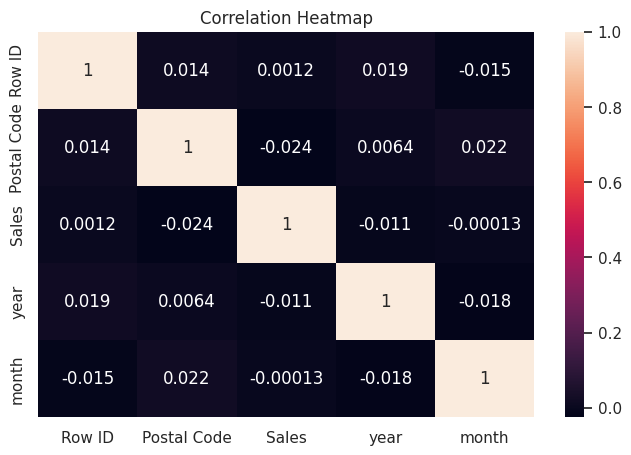

In [24]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Simple Forecasting

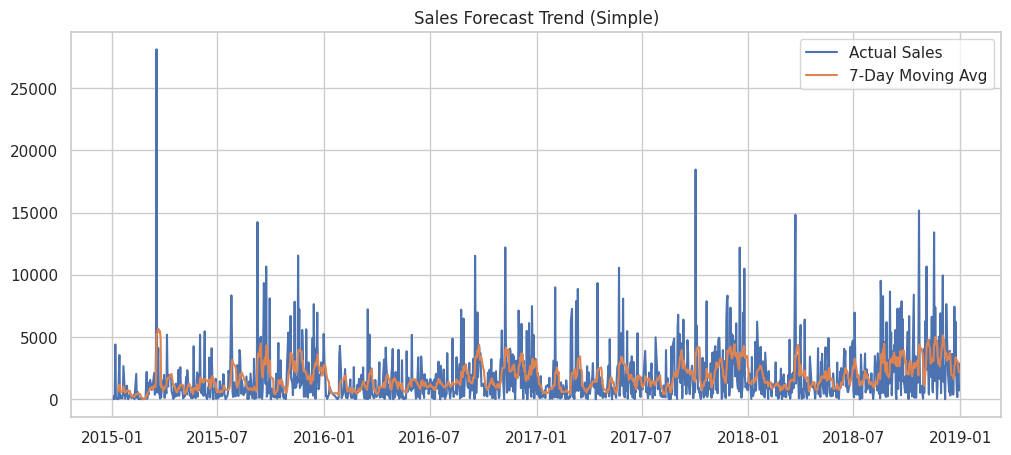

In [25]:
daily_sales_ma = daily_sales.rolling(window=7).mean()

plt.figure(figsize=(12,5))
plt.plot(daily_sales, label='Actual Sales')
plt.plot(daily_sales_ma, label='7-Day Moving Avg')
plt.legend()
plt.title("Sales Forecast Trend (Simple)")
plt.show()

Business Insights

In [26]:
print("Top Store:", store_sales.idxmax())
print("Top Product:", item_sales.idxmax())

print("Peak Sales Month:", monthly_sales.idxmax())
print("Lowest Sales Month:", monthly_sales.idxmin())

Top Store: Technology
Top Product: Canon imageCLASS 2200 Advanced Copier
Peak Sales Month: 11
Lowest Sales Month: 2
